In [ ]:
#Read the csv file to be considered for Multi-classification

In [ ]:
# Seperate the input features and target from the dataset

In [ ]:
 #Transform the categorial into numerical values

In [ ]:
#Split the data  for training  and testing

In [ ]:
#Normalize the input features

In [ ]:
#Define the MLP classifier

In [ ]:
#Train the classifier 

Dataset Output:
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30

Accuracy: 0.9666666666666667
Precision: 0.9696969696969696
Recall: 0.9666666666666667
F1

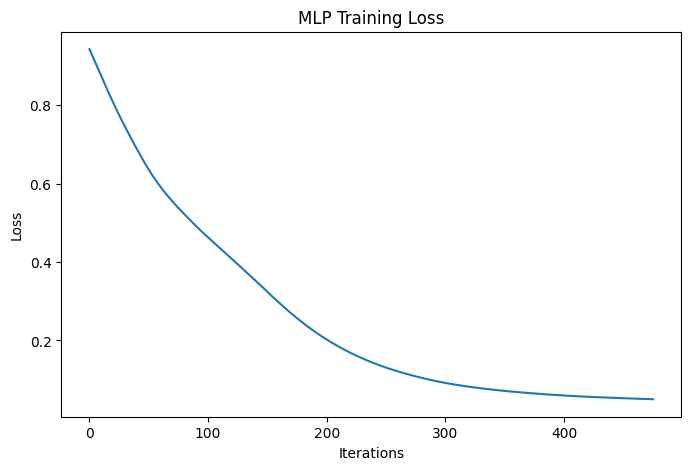

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Load Dataset
data = pd.read_csv("Iris_data.csv")

# Dataset Output
print("Dataset Output:")
print(data.head())

# Features and Target
X = data.drop("species", axis=1)
y = data["species"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Handle Missing Values
imputer = SimpleImputer(strategy="mean")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create MLP Classifier
mlp = MLPClassifier(
    hidden_layer_sizes=(20, 10),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)

# Train Model
mlp.fit(X_train, y_train)

# Predictions
y_pred = mlp.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Additional Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))

# Final Loss
print("Final Loss:", mlp.loss_)

# MLP Training Loss Curve
plt.figure(figsize=(8, 5))

plt.plot(mlp.loss_curve_)

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("MLP Training Loss")

plt.show()